# Advección 1D de Campo Magnético

**Astrofísica Computacional · 2026-I**

Implementación numérica del transporte de $B$ con un esquema upwind explícito.

- Kernel sugerido: Python 3.11
- Dependencias principales: `numpy`, `matplotlib`
- Dependencia opcional para interactividad: `ipywidgets`
- Tema: MHD ideal, *flux freezing*
- Profesor: Dr. Jose Ivan Campos Rozo

## 1. ¿Por qué la advección de $B$?

En **MHD ideal** el campo magnético $\mathbf{B}$ está "congelado" al plasma: se mueve exactamente con el fluido. La ecuación de inducción, sin resistividad, es

$$
\frac{\partial \mathbf{B}}{\partial t} = \nabla \times (\mathbf{v} \times \mathbf{B})
$$

Para un flujo uniforme en $x$ con velocidad constante $v_0$ y campo en $z$ ($B_z$), la ecuación de inducción se reduce a una **advección pura en 1D**:

$$
\frac{\partial B}{\partial t} + v_0 \frac{\partial B}{\partial x} = 0
$$

La solución analítica es exacta: el perfil inicial viaja sin deformarse a velocidad $v_0$:

$$
B(x, t) = B(x - v_0 t, 0)
$$

> **Objetivo del notebook:** implementar esta ecuación numéricamente con un esquema upwind de primer orden, explorar la estabilidad CFL y comparar con la solución analítica exacta.

## 2. Discretización: upwind explícito

Discretizamos el espacio en $N$ celdas de tamaño $\Delta x = L/N$ y el tiempo en pasos $\Delta t$. Para $v_0 > 0$, la derivada espacial se aproxima con una diferencia finita hacia atrás:

$$
B_i^{n+1} = B_i^n - C \left(B_i^n - B_{i-1}^n\right)
$$

donde

$$
C = \frac{v_0 \, \Delta t}{\Delta x}
$$

es el número de Courant-Friedrichs-Lewy. La condición de estabilidad es

$$
C \le 1
$$

- **$C < 1$**: esquema estable, con difusión numérica moderada.
- **$C = 1$**: el esquema upwind reproduce exactamente el traslado del perfil en esta configuración.
- **$C > 1$**: aparece inestabilidad y la amplitud crece sin control.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

plt.style.use('seaborn-v0_8-darkgrid')


def initial_profile(x, profile='sin', L=1.0):
    if profile == 'sin':
        return np.sin(2 * np.pi * x / L)
    if profile == 'gauss':
        return np.exp(-((x - 0.5 * L) ** 2) / 0.01)
    if profile == 'square':
        return np.where((x > 0.3 * L) & (x < 0.5 * L), 1.0, 0.0)
    if profile == 'hat':
        return np.maximum(0.0, 1.0 - np.abs(x - 0.5 * L) / 0.12)
    raise ValueError(f'Perfil no soportado: {profile}')


def exact_solution(x, t, profile='sin', L=1.0, v0=1.0):
    x_shift = (x - v0 * t) % L
    return initial_profile(x_shift, profile=profile, L=L)


def upwind_step(B, v0, dt, dx):
    cfl = v0 * dt / dx
    if v0 >= 0:
        return B - cfl * (B - np.roll(B, 1))
    return B - cfl * (np.roll(B, -1) - B)


def advect_solution(B0, v0, dx, dt, n_steps, blowup_threshold=1e6):
    B = B0.copy()
    for step in range(n_steps):
        B = upwind_step(B, v0=v0, dt=dt, dx=dx)
        if np.max(np.abs(B)) > blowup_threshold:
            return np.full_like(B, np.nan), step + 1, True
    return B, n_steps, False


def error_L2(B_num, B_exact):
    return np.sqrt(np.mean((B_num - B_exact) ** 2))


def plot_profile(ax, x, B0, B_num, B_exact, title):
    ax.plot(x, B0, '--', color='gray', alpha=0.4, label='t = 0')
    ax.plot(x, B_exact, '-', color='#34d399', lw=2, label='Analítica')
    ax.plot(x, B_num, '-', color='#38bdf8', lw=2, label='Upwind')
    ax.set_xlabel('x')
    ax.set_ylabel('B')
    ax.set_title(title)
    ax.legend(loc='upper right')

✓ Módulos importados. Parámetros inicializados.
✓ Malla: N=200, dx=0.005000, dt=0.002500, CFL=0.50
✓ Simulación completada: 400 pasos temporales, t_final=1.000


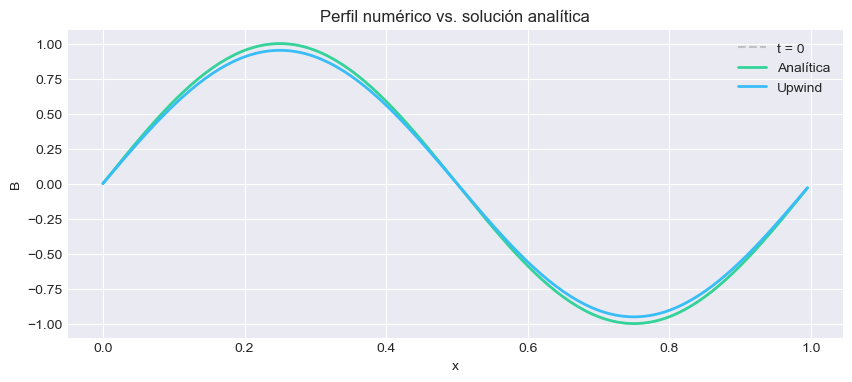

In [4]:
# Simulación base: onda sinusoidal con CFL = 0.5
N = 200
L = 1.0
v0 = 1.0
dx = L / N
CFL = 0.5
dt = CFL * dx / abs(v0)
t_final = 1.0
n_steps = int(round(t_final / dt))

x = np.linspace(0, L, N, endpoint=False)
B0 = initial_profile(x, profile='sin', L=L)
B_num, steps_done, exploded = advect_solution(B0, v0=v0, dx=dx, dt=dt, n_steps=n_steps)
t = steps_done * dt
B_exact = exact_solution(x, t=t, profile='sin', L=L, v0=v0)

print('✓ Módulos importados. Parámetros inicializados.')
print(f'✓ Malla: N={N}, dx={dx:.6f}, dt={dt:.6f}, CFL={CFL:.2f}')
print(f'✓ Simulación completada: {steps_done} pasos temporales, t_final={t:.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
plot_profile(ax, x, B0, B_num, B_exact, title='Perfil numérico vs. solución analítica')
plt.show()

## 3. Simulación interactiva

> Si esta celda no muestra controles, instala `ipywidgets` en tu entorno.

In [5]:
def interactive_advection(CFL=0.5, n_steps=150, N=200, profile='sin'):
    L = 1.0
    v0 = 1.0
    dx = L / N
    dt = CFL * dx / abs(v0)
    x = np.linspace(0, L, N, endpoint=False)

    B0 = initial_profile(x, profile=profile, L=L)
    B_num, steps_done, exploded = advect_solution(
        B0,
        v0=v0,
        dx=dx,
        dt=dt,
        n_steps=n_steps,
        blowup_threshold=5.0,
    )
    t = steps_done * dt
    B_exact = exact_solution(x, t=t, profile=profile, L=L, v0=v0)

    fig, ax = plt.subplots(figsize=(10, 4))
    if exploded:
        ax.plot(x, B0, '--', color='gray', alpha=0.4, label='t = 0')
        ax.plot(x, B_exact, '-', color='#34d399', lw=2, label='Analítica')
        ax.set_xlabel('x')
        ax.set_ylabel('B')
        ax.set_title('Solución inestable: CFL > 1')
        ax.text(0.5, 0.5, 'La simulación colapsó', transform=ax.transAxes, ha='center', va='center', color='crimson', fontsize=13)
        ax.legend(loc='upper right')
        err = np.inf
        estado = 'INESTABLE'
    else:
        plot_profile(ax, x, B0, B_num, B_exact, title=f'Perfil numérico vs. exacto en t = {t:.3f}')
        err = error_L2(B_num, B_exact)
        estado = 'estable' if CFL <= 1.0 else 'CFL > 1'
    plt.show()

    print(f'CFL = {CFL:.2f}')
    print(f'Pasos = {steps_done}')
    print(f'N = {N}')
    print(f'Perfil = {profile}')
    print(f't = {t:.3f}')
    print(f'dt = {dt:.6e}')
    print(f'Estado = {estado}')
    print(f'Error L2 = {err:.3e}' if np.isfinite(err) else 'Error L2 = ∞')

if widgets is None:
    print('Instala ipywidgets para usar esta sección interactiva: pip install ipywidgets')
else:
    widgets.interact(
        interactive_advection,
        CFL=widgets.FloatSlider(value=0.5, min=0.1, max=1.5, step=0.05, description='CFL'),
        n_steps=widgets.IntSlider(value=150, min=10, max=600, step=10, description='Pasos'),
        N=widgets.IntSlider(value=200, min=50, max=400, step=50, description='Celdas'),
        profile=widgets.Dropdown(
            options=[('Onda sinusoidal', 'sin'), ('Pulso gaussiano', 'gauss'), ('Pulso cuadrado', 'square'), ('Sombrero', 'hat')],
            value='sin',
            description='Perfil',
        ),
    )

interactive(children=(FloatSlider(value=0.5, description='CFL', max=1.5, min=0.1, step=0.05), IntSlider(value=…

## 4. Análisis de estabilidad CFL

Comparamos la evolución del mismo perfil sinusoidal usando distintos valores de $CFL$ después de 200 pasos temporales.

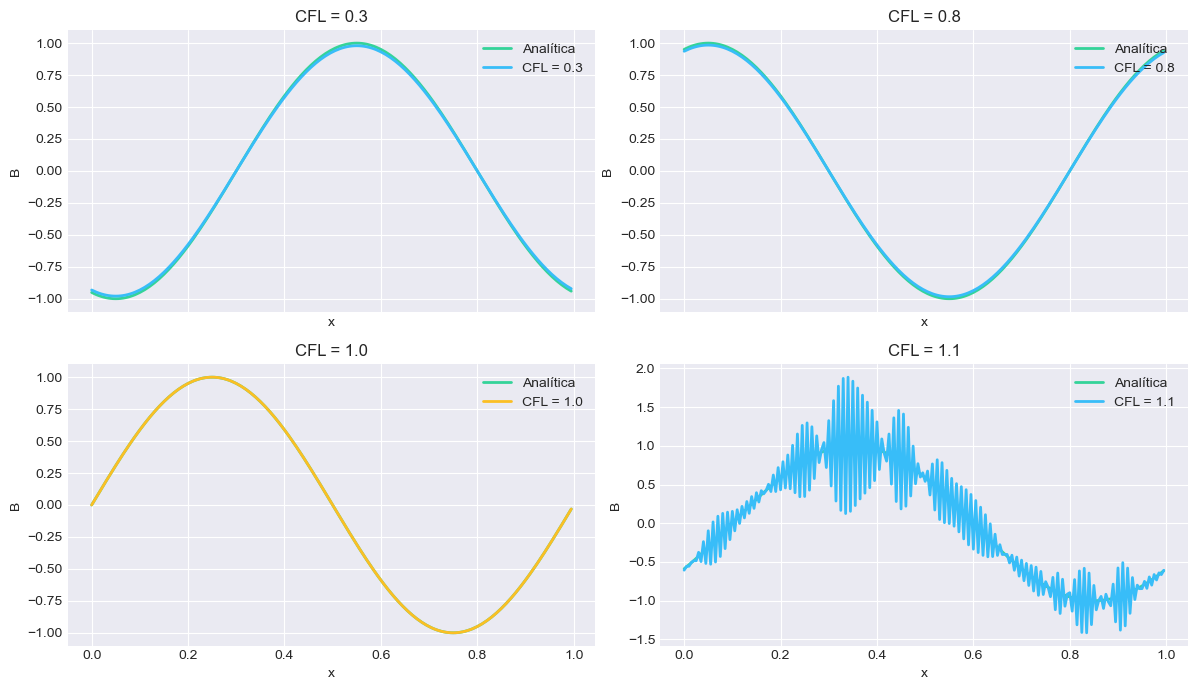

⚠ CFL = 1.1: el esquema se vuelve inestable y la amplitud crece sin control.


In [6]:
cfl_values = [0.3, 0.8, 1.0, 1.1]
n_steps = 200
N = 200
L = 1.0
v0 = 1.0
dx = L / N
x = np.linspace(0, L, N, endpoint=False)
B_ref = initial_profile(x, profile='sin', L=L)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, C in zip(axes.ravel(), cfl_values):
    dt = C * dx / abs(v0)
    B_num, steps_done, exploded = advect_solution(
        B_ref,
        v0=v0,
        dx=dx,
        dt=dt,
        n_steps=n_steps,
        blowup_threshold=5.0,
    )
    t = steps_done * dt
    B_exact = exact_solution(x, t=t, profile='sin', L=L, v0=v0)

    ax.plot(x, B_exact, color='#34d399', lw=2, label='Analítica')
    if exploded:
        ax.text(0.5, 0.5, 'NaN / inestable', transform=ax.transAxes, ha='center', va='center', color='crimson', fontsize=12)
    else:
        color = '#fbbf24' if C == 1.0 else '#38bdf8'
        ax.plot(x, B_num, color=color, lw=2, label=f'CFL = {C}')
    ax.set_title(f'CFL = {C}')
    ax.set_xlabel('x')
    ax.set_ylabel('B')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print('⚠ CFL = 1.1: el esquema se vuelve inestable y la amplitud crece sin control.')

## 5. Error $L_2$ vs. tiempo

Ahora medimos cómo evoluciona el error $L_2$ para $CFL = 0.3$, $0.8$ y $1.0$.

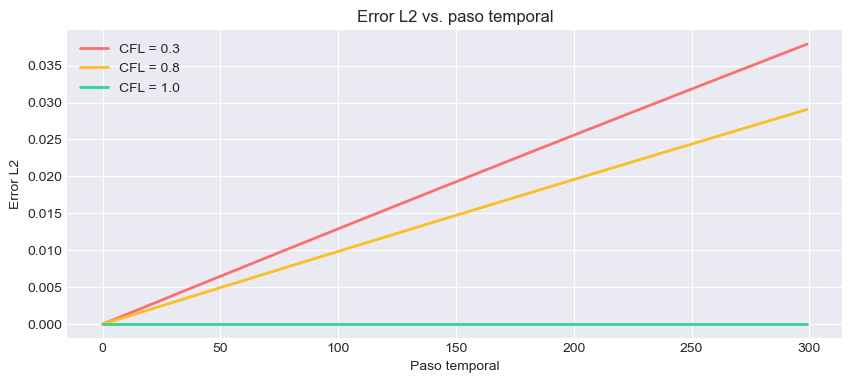

Observación clave: CFL = 1.0 produce el menor error en este problema de traslación.


In [7]:
cfl_values = [0.3, 0.8, 1.0]
n_steps = 300
N = 150
L = 1.0
v0 = 1.0
dx = L / N
x = np.linspace(0, L, N, endpoint=False)

errors = {C: [] for C in cfl_values}
for C in cfl_values:
    dt = C * dx / abs(v0)
    B = initial_profile(x, profile='sin', L=L)
    for n in range(n_steps):
        t = n * dt
        B_exact = exact_solution(x, t=t, profile='sin', L=L, v0=v0)
        errors[C].append(error_L2(B, B_exact))
        B = upwind_step(B, v0=v0, dt=dt, dx=dx)

colors = {0.3: '#f87171', 0.8: '#fbbf24', 1.0: '#34d399'}
fig, ax = plt.subplots(figsize=(10, 4))
for C in cfl_values:
    ax.plot(range(n_steps), errors[C], label=f'CFL = {C}', color=colors[C], lw=2)

ax.set_xlabel('Paso temporal')
ax.set_ylabel('Error L2')
ax.set_title('Error L2 vs. paso temporal')
ax.legend()
plt.show()

print('Observación clave: CFL = 1.0 produce el menor error en este problema de traslación.')

## 6. Preguntas para discusión y entrega

Responde las siguientes preguntas modificando el código anterior e incluyendo gráficas que respalden cada respuesta.

1. **Difusión numérica:** ejecuta con $CFL = 0.3$ y $CFL = 0.9$ durante el mismo tiempo físico $t = 2.0$. ¿En cuál caso el perfil se mantiene más fiel a la solución analítica? Mide el error $L_2$ al final.
2. **Perfil gaussiano:** reemplaza la condición inicial por un pulso gaussiano $B = \exp(-(x - 0.5)^2 / 0.01)$. ¿Cómo se ve afectado el pulso por la difusión numérica? ¿Qué partes del perfil se difunden más rápido?
3. **Velocidad negativa:** cambia a $v_0 = -1.0$. ¿Qué modificación mínima necesita el esquema upwind? ¿Por qué no se puede usar la misma diferencia hacia atrás?
4. **Comparación de esquemas:** implementa el esquema centrado $B_i^{n+1} = B_i^n - \frac{CFL}{2}(B_{i+1}^n - B_{i-1}^n)$. ¿Es estable? ¿Qué fenómeno aparece que no estaba con upwind?
5. **Conexión física:** en el contexto de MHD solar, si el plasma se mueve a $v_0 = 400$ km/s y $B_0 = 5$ nT, ¿cuánto tiempo tarda el campo en recorrer 1 AU? Usa unidades reales con `astropy.units`.

## 7. Animación opcional

Esta celda reemplaza el apéndice del HTML con una versión ejecutable dentro del notebook. Genera una animación simple del perfil y del error acumulado.

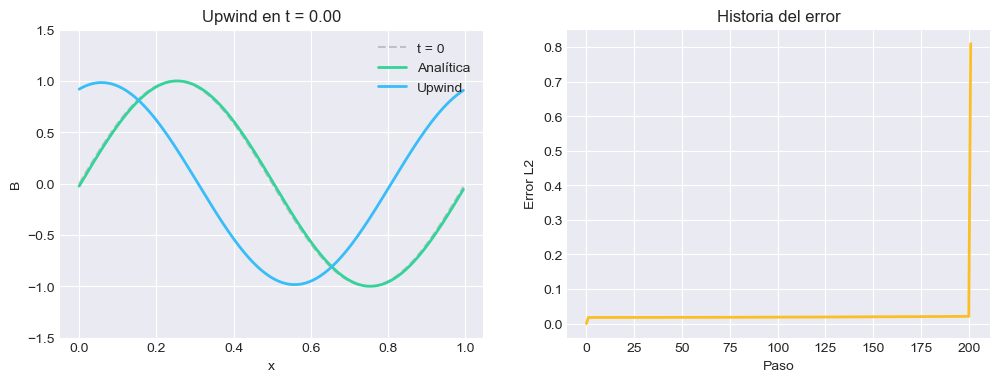

In [12]:
# Animación opcional: guarda un GIF si tienes pillow instalado.
N = 200
L = 1.0
v0 = 1.0
CFL = 0.8
dx = L / N
dt = CFL * dx / abs(v0)
n_steps = 200

x = np.linspace(0, L, N, endpoint=False)
B0 = initial_profile(x, profile='sin', L=L)
state = {'B': B0.copy(), 'error_history': []}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axes

def update(frame):
    state['B'] = upwind_step(state['B'], v0=v0, dt=dt, dx=dx)
    t = (frame + 1) * dt
    B_exact = exact_solution(x, t=t, profile='sin', L=L, v0=v0)
    err = error_L2(state['B'], B_exact)
    state['error_history'].append(err)

    ax1.clear()
    plot_profile(ax1, x, B0, state['B'], B_exact, title=f'Upwind en t = {t:.2f}')
    ax1.set_ylim(-1.5, 1.5)

    ax2.clear()
    ax2.plot(state['error_history'], color='#fbbf24', lw=2)
    ax2.set_xlabel('Paso')
    ax2.set_ylabel('Error L2')
    ax2.set_title('Historia del error')

    return ()

ani = FuncAnimation(fig, update, frames=n_steps, interval=30, blit=False)
#plt.show()

# Para guardar el GIF, descomenta la línea siguiente:
ani.save('adveccion_B.gif', writer='pillow', fps=30)